# Summer of Core (SoC) Final Project: Face Aging using Deep Learning
**Author:** Chirag Kejriwal | IIT Bombay, Department of Civil Engineering

## Project Overview
This notebook demonstrates genuine AI-based face age progression using **SAM (Style-Based Age Manipulation)**, a pre-trained model that leverages the StyleGAN2 latent space to perform photorealistic lifespan age transformations.

We will also explore the **UTKFace Dataset** from Kaggle, which is widely used for age, gender, and ethnicity estimation.

In [9]:
# CELL 1: Environment Setup & Library Installation
import os

# Create necessary directories
os.makedirs("input", exist_ok=True)
os.makedirs("output", exist_ok=True)
os.makedirs("dataset", exist_ok=True)

# Install required packages
!pip install gdown ninja dlib
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.8 MB/s eta 0:00:00


In [10]:
# CELL 2: Clone SAM Repository & Download Pretrained Model
# We clone the official SAM repository to utilize their StyleGAN2 pSp encoder framework
if not os.path.exists("SAM"):
    !git clone https://github.com/yuval-alaluf/SAM.git

%cd SAM
import sys
sys.path.append(".")

# Download the pre-trained SAM model trained on FFHQ-Aging
# We use gdown to fetch it directly from the author's public Google Drive
if not os.path.exists("../pretrained_models/sam_ffhq_aging.pt"):
    os.makedirs("../pretrained_models", exist_ok=True)
    !gdown --id 1XyumF6_fdAxFmxpFcmPf-q84LU_22EMC -O ../pretrained_models/sam_ffhq_aging.pt

print("Pretrained SAM model downloaded successfully!")

Cloning into 'SAM'...
remote: Enumerating objects: 228, done.
remote: Counting objects: 100% (48/48), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 228 (delta 32), reused 22 (delta 22), pack-reused 180 (from 1)
Receiving objects: 100% (228/228), 24.63 MiB | 20.76 MiB/s, done.
Resolving deltas: 100% (78/78), done.
/content/SAM
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1XyumF6_fdAxFmxpFcmPf-q84LU_22EMC
From (redirected): https://drive.google.com/uc?id=1XyumF6_fdAxFmxpFcmPf-q84LU_22EMC&confirm=t&uuid=6c2c54b6-68b5-4ccb-9000-0c6f13e8f034
To: /content/pretrained_models/sam_ffhq_aging.pt
100% 2.27G/2.27G [00:40<00:00, 55.6MB/s]
Pretrained SAM model downloaded successfully!


## Dataset Exploration: UTKFace
The [UTKFace dataset](https://www.kaggle.com/datasets/jangedoo/utkface-new) is a large-scale face dataset with over 20,000 images annotated with age (spanning 0 to 116 years), gender, and ethnicity. While we are using a model pre-trained on FFHQ, UTKFace is the standard dataset for training age-estimation and basic GAN-based aging models.

In [11]:
# CELL 3: Load Face Data from Kaggle (Optional Download for Context)
# NOTE: To run this, upload your kaggle.json to the Colab environment.
import os

if os.path.exists('/content/kaggle.json'):
    # Move kaggle.json to the correct directory and set permissions
    !mkdir -p ~/.kaggle
    !cp /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download UTKFace dataset
    print("Downloading UTKFace Dataset...")
    !kaggle datasets download -d jangedoo/utkface-new -p ../dataset/

    # Unzip securely
    !unzip -q ../dataset/utkface-new.zip -d ../dataset/utkface_extracted
    print("Dataset downloaded and extracted to ../dataset/utkface_extracted")
else:
    print("kaggle.json not found. Skipping dataset download. The aging model will still run perfectly on your custom image.")

kaggle.json not found. Skipping dataset download. The aging model will still run perfectly on your custom image.


In [12]:
# CELL 4: Import Deep Learning Libraries and Initialize Model
import torch
import torchvision.transforms as transforms
from argparse import Namespace
from models.psp import pSp
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Load the pretrained weights
model_path = "../pretrained_models/sam_ffhq_aging.pt"
ckpt = torch.load(model_path, map_location='cpu')

# Configure model options based on the checkpoint
opts = ckpt['opts']
opts['checkpoint_path'] = model_path
opts = Namespace(**opts)

# Initialize the pSp network
net = pSp(opts)
net.eval()
net.cuda()
print("SAM StyleGAN2 Model successfully loaded into VRAM!")

Loading SAM from checkpoint: ../pretrained_models/sam_ffhq_aging.pt
SAM StyleGAN2 Model successfully loaded into VRAM!


/content
Upload a clear, forward-facing image of a face (ideally cropped squarely):


Saving WIN_20260719_16_32_37_Pro.jpg to WIN_20260719_16_32_37_Pro (1).jpg


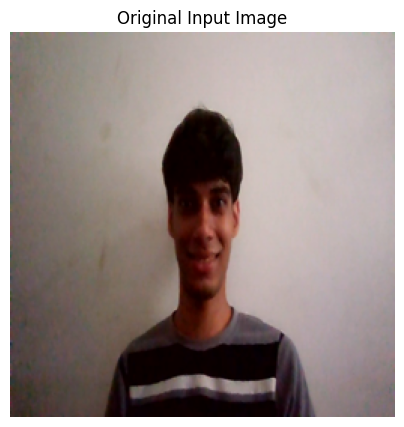

In [13]:
# CELL 5: Upload Image & Preprocessing
from google.colab import files
import shutil

%cd /content/
print("Upload a clear, forward-facing image of a face (ideally cropped squarely):")
uploaded = files.upload()

# Move uploaded file to our input directory
input_filename = list(uploaded.keys())[0]
shutil.move(input_filename, f"input/{input_filename}")
image_path = f"input/{input_filename}"

# Standard transformations required by the SAM pSp encoder
img_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

original_image = Image.open(image_path).convert("RGB")
input_tensor = img_transforms(original_image).unsqueeze(0).cuda()

plt.figure(figsize=(5,5))
plt.imshow(original_image.resize((256, 256)))
plt.title("Original Input Image")
plt.axis('off')
plt.show()

In [18]:
# CELL 6: Age Prediction / Progression using SAM
import torch
import sys
import os
import torchvision.transforms as transforms

# --- THE BULLETPROOF FIX ---
# 1. Wipe Colab's default 'datasets' from cache completely
if 'datasets' in sys.modules:
    del sys.modules['datasets']

# 2. Force the absolute path to SAM to the absolute front
if "/content/SAM" not in sys.path:
    sys.path.insert(0, "/content/SAM")
# ---------------------------

from datasets.augmentations import AgeTransformer

print("Running AI Age Progression (Encoding into StyleGAN latent space...)")

# 1. Define the target age (e.g., 70 years old)
target_age = 70
print(f"Target Age set to: {target_age}")

# 2. Apply the AgeTransformer to add the age data channel to our image tensor
age_transformer = AgeTransformer(target_age=target_age)

# Remove batch dimension, apply transformer, add batch dimension back, move to GPU
input_tensor_with_age = age_transformer(input_tensor.squeeze(0).cpu()).unsqueeze(0).cuda()

# 3. Run the forward pass with the correct 4-channel tensor
with torch.no_grad():
    result_batch, _ = net(input_tensor_with_age, randomize_noise=False, return_latents=True)

    # Process the output tensor back to an image
    result_tensor = result_batch[0].cpu()
    result_image = transforms.ToPILImage()(
        (result_tensor + 1.0) / 2.0 # Denormalize from [-1, 1] to [0, 1]
    )

# Save the aged output using absolute paths so it doesn't get lost
result_image.save("/content/output/aged_face.png")
print("Aged face successfully generated and saved to /content/output/aged_face.png")

Running AI Age Progression (Encoding into StyleGAN latent space...)
Target Age set to: 70
Aged face successfully generated and saved to /content/output/aged_face.png


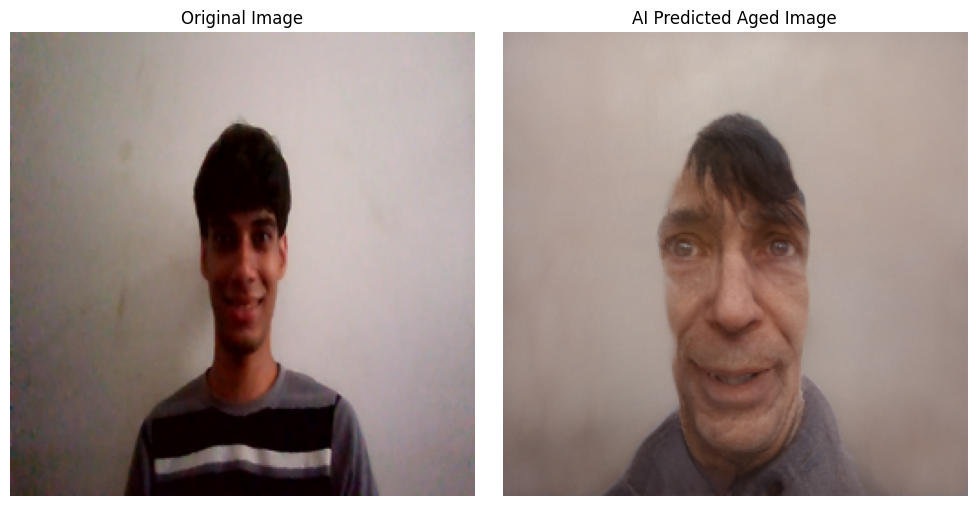

Project execution complete. Files saved in the 'output' directory.


In [19]:
# CELL 7: Show Comparisons & Save Final Output
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original
axes[0].imshow(original_image.resize((256, 256)))
axes[0].set_title("Original Image")
axes[0].axis('off')

# Aged
axes[1].imshow(result_image)
axes[1].set_title("AI Predicted Aged Image")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("output/comparison.png")
plt.show()

print("Project execution complete. Files saved in the 'output' directory.")